# Generating dataset

In [45]:
# importing libraries
import pandas as pd
import matplotlib.pyplot as plt

In [46]:
# reading sample data
df = pd.read_csv('data/weekly hours studied vs marks.csv')
print('Shape of DataFrame :',df.shape)
df.head(10)

Shape of DataFrame : (100, 2)


,Hours,Marks
0,40,98
1,37,40
2,28,68
3,12,33
4,15,80
5,33,80
6,24,63
7,39,99
8,17,42
9,22,50


In [47]:
print(df.dtypes)
print(df.isnull().sum())

Hours    int64
Marks    int64
dtype: object
Hours    0
Marks    0
dtype: int64


In [48]:
df.describe()

,Hours,Marks
count,100.000000,100.000000
mean,20.780000,51.880000
std,11.136055,27.006651
min,0.000000,2.000000
25%,11.750000,30.000000
50%,20.500000,50.000000
75%,30.000000,74.500000
max,40.000000,100.000000


In [49]:
print('correlation :', df['Hours'].corr(df['Marks']))

correlation : 0.8476642071709332


In [ ]:
from sklearn.model_selection import train_test_split

X = df[['Hours']].values # keep X as 2D array 
y = df['Marks'].values #keeps y as 1D array 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(80, 1) (20, 1) (80,) (20,)


# Gradient Descent Algorithm

In [ ]:
#initialising parameters
w = 0.0 # weight of hours studied
b = 0.0 # bias 
alpha = 0.0001 # learning rate


def predict(X, w, b):
    ypred = X * w + b
    return ypred.flatten()

y_pred = predict(X_train, w, b)
print(y_pred[:5])


[0. 0. 0. 0. 0.]


In [ ]:
def compute_cost(y_train, y_pred):
    n = len(y_train)
    cost = (1/(n)) * sum((y_pred - y_train)**2) # Mean Squared Error

    return cost
print("Cost:", compute_cost(y_train, y))

Cost: 3340.5750000000003


In [ ]:
def computegradient(X_train, y_train, y_pred):
    n = len(y_train)
    dw = (1/n) * sum((y_pred - y_train) * X_train.flatten()) # dw is the gradient of the weight
    db = (1/n) * sum(y_pred - y_train) # db is the gradient of the bias

    return dw, db

dw, db = computegradient(X_train, y_train, y_pred)
print("dw:", dw)
print("db:", db)

dw: -1301.9250000000002
db: -51.425000000000004


In [71]:
w = w - alpha * dw
b = b - alpha * db

print("Updated weight after one iteration:", w)
print("Updated bias after one iteration:", b)

Updated weight after one iteration: 0.13019250000000002
Updated bias after one iteration: 0.0051425


In [81]:
# creating a function to train the model

def train_gradient_descent(X_train, y_train, w, b, alpha, epochs):
    costs = []
    for i in range(epochs):
        y_pred = predict(X_train, w, b)
        cost = compute_cost(y_train, y_pred)
        costs.append(cost)
        dw, db = computegradient(X_train, y_train, y_pred)
        w = w - alpha * dw
        b = b - alpha * db
        if i % 25 == 0:
            print(f"Epoch {i}: Cost {round(cost, 4)}, Weight {round(w, 4)}, Bias {round(b, 4)}")
    return round(w,4), round(b,4), costs



In [82]:
#reinitialising parameters
w = 0.0 # weight of hours studied
b = 0.0 # bias 
alpha = 0.0001 # learning rate
epochs = 500 # number of iterations

w, b, costs = train_gradient_descent(X_train, y_train, w, b, alpha, epochs)


Epoch 0: Cost 3340.575, Weight 0.1302, Bias 0.0051
Epoch 25: Cost 390.4575, Weight 1.8425, Bias 0.0754
Epoch 50: Cost 206.1313, Weight 2.2703, Bias 0.0972
Epoch 75: Cost 194.5922, Weight 2.377, Bias 0.1069
Epoch 100: Cost 193.8476, Weight 2.4036, Bias 0.1135
Epoch 125: Cost 193.7774, Weight 2.41, Bias 0.1194
Epoch 150: Cost 193.7493, Weight 2.4115, Bias 0.1251
Epoch 175: Cost 193.7239, Weight 2.4117, Bias 0.1307
Epoch 200: Cost 193.6987, Weight 2.4116, Bias 0.1363
Epoch 225: Cost 193.6736, Weight 2.4114, Bias 0.1419
Epoch 250: Cost 193.6484, Weight 2.4112, Bias 0.1475
Epoch 275: Cost 193.6233, Weight 2.411, Bias 0.1531
Epoch 300: Cost 193.5983, Weight 2.4108, Bias 0.1587
Epoch 325: Cost 193.5732, Weight 2.4106, Bias 0.1643
Epoch 350: Cost 193.5482, Weight 2.4104, Bias 0.1699
Epoch 375: Cost 193.5232, Weight 2.4102, Bias 0.1755
Epoch 400: Cost 193.4983, Weight 2.4099, Bias 0.1811
Epoch 425: Cost 193.4733, Weight 2.4097, Bias 0.1866
Epoch 450: Cost 193.4485, Weight 2.4095, Bias 0.1922
Ep

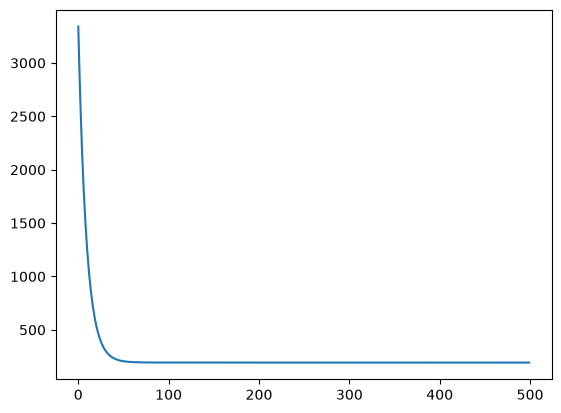

In [ ]:
# Plotting the cost function
plt.plot(range(epochs), costs)


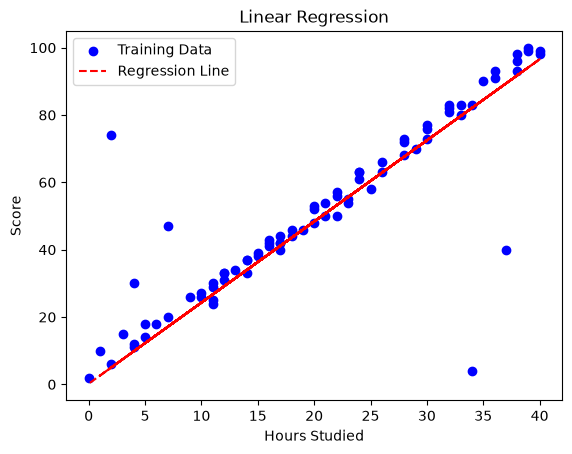

In [84]:
# regression line
plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.plot(X_train, predict(X_train, w, b), color='red', label='Regression Line', linestyle='--')
plt.xlabel('Hours Studied')
plt.ylabel('Score')
plt.title('Linear Regression')
plt.legend()
plt.show()

In [85]:
# testing the model on test data
y_test_pred = predict(X_test, w, b) 
#printing the predicted values
print("Predicted values:", y_test_pred)

Predicted values: [82.1125 19.4759 19.4759 72.4761 60.4306 19.4759 24.2941 67.6579 65.2488
 96.5671 60.4306 84.5216 33.9305 62.8397 17.0668 36.3396 48.3851 53.2033
 89.3398 77.2943]


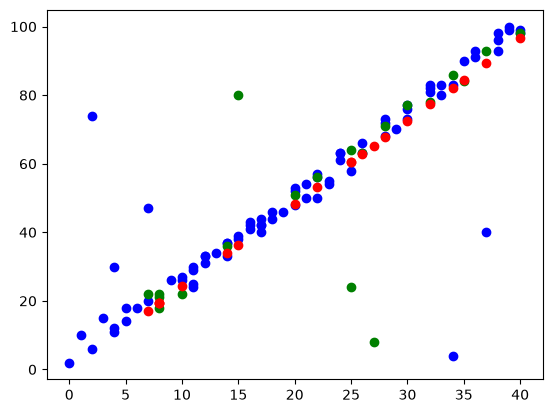

In [87]:
# Actual vs Predicted values plot along with training data

plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.scatter(X_test, y_test, color='green', label='Actual Values')
plt.scatter(X_test, y_test_pred, color='red', label='Predicted Values')

In [88]:
# testing the model on test data
y_test_pred = predict(X_test, w, b)
# accuracy of the model
from sklearn.metrics import r2_score    
r2 = r2_score(y_test, y_test_pred)
print("R-squared value:", r2)

R-squared value: 0.5957474649694043
